# 1.Category Contribution and Reviews Distribution

/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1277736165.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


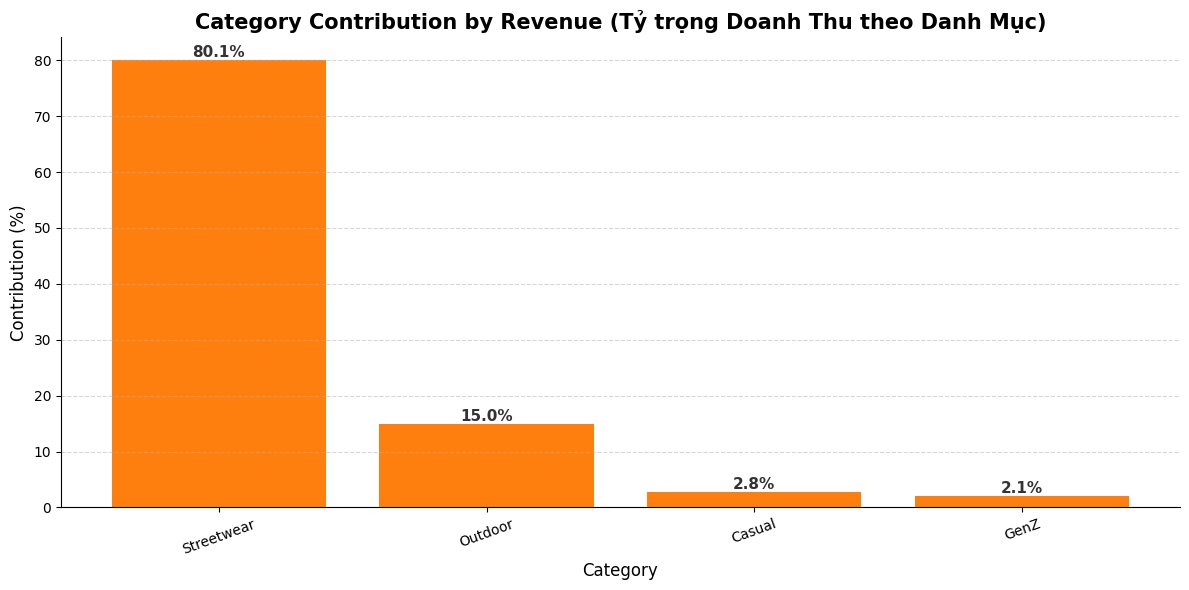

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')

# 2. Merge dữ liệu để lấy category cho từng item dựa vào product_id
order_items_merged = order_items.merge(products[['product_id', 'category']], on='product_id', how='inner')

# 3. Tính doanh thu (Revenue) cho mỗi sản phẩm bán ra
order_items_merged['revenue'] = (order_items_merged['quantity'] * order_items_merged['unit_price']) - order_items_merged['discount_amount'].fillna(0)

# 4. Gom nhóm tính tổng doanh thu theo Category 
category_revenue = order_items_merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

# 5. Phân tích tỷ trọng phần trăm (Contribution)
total_revenue = category_revenue.sum()
category_percentage = (category_revenue / total_revenue) * 100

# ==========================================
# Vẽ biểu đồ Bar Chart Percentage
# ==========================================
plt.figure(figsize=(12, 6))
bars = plt.bar(category_percentage.index, category_percentage.values, color='#ff7f0e')

# Thêm số % lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#333333')

plt.title('Category Contribution by Revenue (Tỷ trọng Doanh Thu theo Danh Mục)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Contribution (%)', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Bỏ viền thừa của biểu đồ cho thiết kế thanh thoát hơn
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


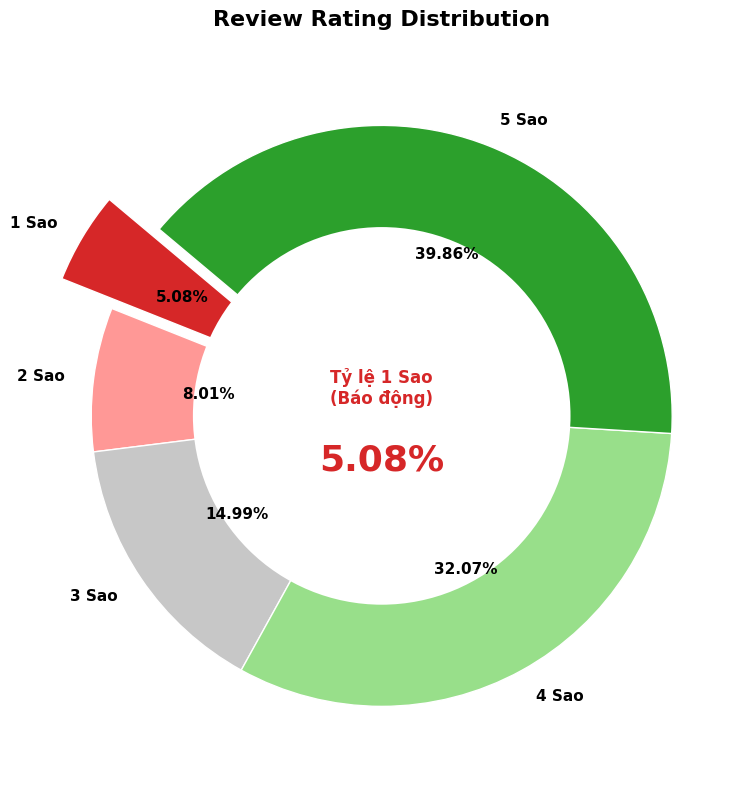

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu đánh giá
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv')

# 2. Đếm số lượng theo giá trị rating (từ 1 đến 5 sao)
rating_counts = reviews['rating'].value_counts()
total_reviews = len(reviews)

# Chuẩn hóa thứ tự index từ 1 đến 5 sao (với mapping string)
mapping = {1: '1 Sao', 2: '2 Sao', 3: '3 Sao', 4: '4 Sao', 5: '5 Sao'}
rating_counts.index = rating_counts.index.map(mapping)
rating_counts = rating_counts.reindex(['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao']).fillna(0)

# 3. Tính % tỷ lệ phân bổ của các sao
percentage = rating_counts / total_reviews

# ==========================================
# Vẽ biểu đồ Donut Chart (Highlight 1 Sao bị vỡ ra khỏi bánh)
# ==========================================
# Set màu: Trắng/đỏ để nhấn mạnh sự tiêu cực của 1 sao, các review cao dần thì xanh lá
colors = ['#d62728', '#ff9896', '#c7c7c7', '#98df8a', '#2ca02c'] 
explode = (0.2, 0, 0, 0, 0)  # Tách lát cắt 1 sao (index 0) ra khỏi bánh

plt.figure(figsize=(8, 8))
plt.pie(percentage, explode=explode, labels=percentage.index, colors=colors, 
        autopct='%1.2f%%', startangle=140, textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops=dict(edgecolor='w'))

# Thêm vòng tròn trắng ở giữa để tạo thành Donut chart đương đại
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# In số liệu đúc kết của phần 1 Sao ngay ở giữa tâm chart!
one_star_pct = percentage.get('1 Sao', 0)
plt.text(0, 0.1, 'Tỷ lệ 1 Sao\n(Báo động)', ha='center', va='center', fontsize=12, color='#d62728', fontweight='bold')
plt.text(0, -0.15, f'{one_star_pct:.2%}', ha='center', va='center', fontsize=26, color='#d62728', fontweight='bold')

plt.title('Review Rating Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 2. Sentiment Analysis

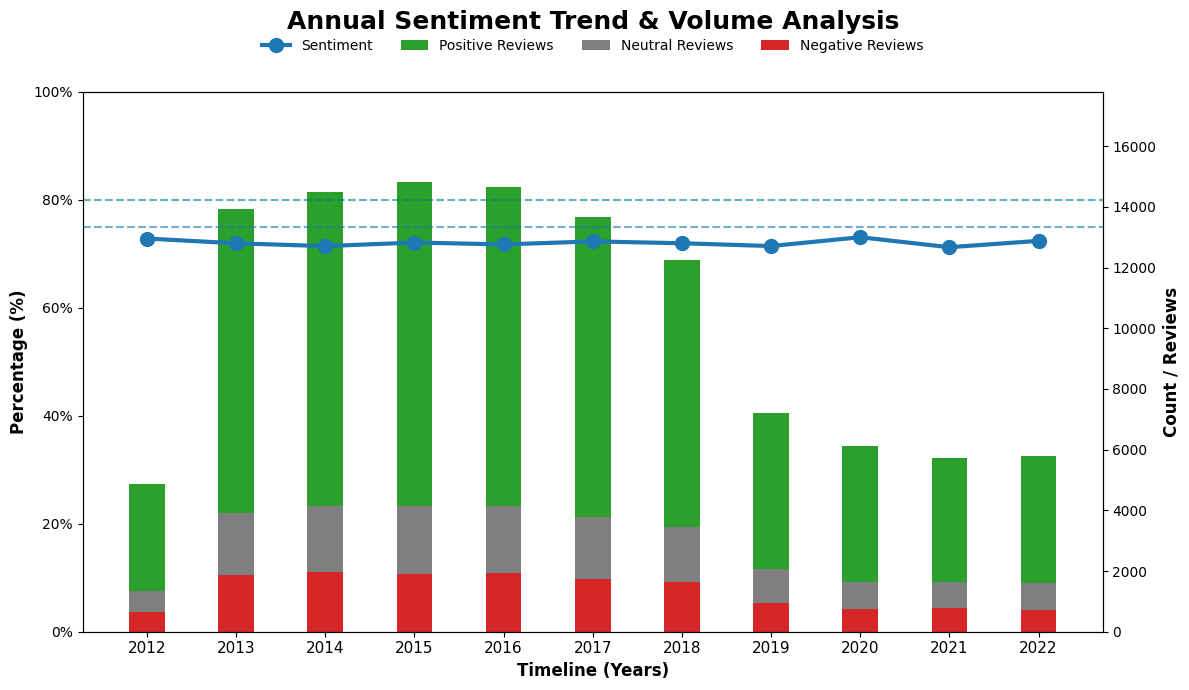

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Đọc dữ liệu (Bỏ lọc năm 2022 để lấy toàn bộ các năm có trong data)
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv', parse_dates=['review_date'])

# 2. Phân loại Cảm xúc (Sentiment Rating)
def classify_rating(r):
    if r in [1, 2]: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

reviews['sentiment'] = reviews['rating'].apply(classify_rating)

reviews['Year'] = reviews['review_date'].dt.year

# 3. Gom nhóm theo Năm
pivot = reviews.groupby(['Year', 'sentiment']).size().unstack(fill_value=0)

# Đảm bảo có đủ 3 cột
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in pivot.columns:
        pivot[col] = 0

pivot['Total'] = pivot['Negative'] + pivot['Neutral'] + pivot['Positive']
pivot['Sentiment_Pct'] = (pivot['Positive'] / pivot['Total']) * 100

# Chuẩn bị dữ liệu vẽ
x_labels = pivot.index.astype(str).tolist()
pos = pivot['Positive'].values
neu = pivot['Neutral'].values
neg = pivot['Negative'].values
sentiment_line = pivot['Sentiment_Pct'].values

# ==========================================
# VẼ BIỂU ĐỒ KÉP (DUAL AXIS CHART)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 7))

# Trục phụ ax2 (Cột chồng - Secondary Right Y-Axis)
ax2 = ax1.twinx()
width = 0.4 # Giảm độ rộng cột vì số lượng năm thường ít hơn số tháng
x_pos = np.arange(len(x_labels))

# Vẽ cột chồng
p_neg = ax2.bar(x_pos, neg, width, label='Negative Reviews', color='#d62728', zorder=2)
p_neu = ax2.bar(x_pos, neu, width, bottom=neg, label='Neutral Reviews', color='#7f7f7f', zorder=2)
p_pos = ax2.bar(x_pos, pos, width, bottom=neg+neu, label='Positive Reviews', color='#2ca02c', zorder=2)

ax2.set_ylabel('Count / Reviews', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(pivot['Total']) * 1.2) 

# Trục chính ax1 (Line - Primary Left Y-Axis)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

p_line, = ax1.plot(x_pos, sentiment_line, color='#1f77b4', marker='o', markersize=10, 
                   linewidth=3, label='Sentiment', zorder=3)

ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Đường Tham Chiếu
ax1.axhline(75, color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
ax1.axhline(80, color='#008080', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

# Format Trục hoành theo Năm
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=11)
ax1.set_xlabel('Timeline (Years)', fontsize=12, fontweight='bold')

# Legend & Summary
handles = [p_line, p_pos, p_neu, p_neg]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

plt.title('Annual Sentiment Trend & Volume Analysis', pad=45, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
display(pivot)

sentiment,Negative,Neutral,Positive,Total,Sentiment_Pct
Year,,,,,
2012,650,678,3551,4879,72.781308
2013,1859,2059,10024,13942,71.897863
2014,1974,2174,10347,14495,71.383236
2015,1901,2246,10687,14834,72.043953
2016,1928,2220,10505,14653,71.691804
2017,1736,2060,9883,13679,72.249433
2018,1629,1809,8801,12239,71.909470
2019,948,1109,5134,7191,71.394799
2020,741,906,4459,6106,73.026531


/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/63934321.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


PHÂN KHÚC (SEGMENT)  | ĐỊNH HƯỚNG QUYẾT ĐỊNH                  | AVG LTV KHÁCH   | TỔNG BÁN RA
Everyday             | Cash Cows (Vắt sữa cơ bản)             | $36,768         | 743,849 Sp
Balanced             | Stars (Mũi nhọn - Đẩy mạnh)            | $39,794         | 421,216 Sp
Activewear           | Stars (Mũi nhọn - Đẩy mạnh)            | $39,259         | 941,024 Sp
Performance          | Cash Cows (Vắt sữa cơ bản)             | $37,892         | 396,226 Sp
Trendy               | Dogs (Kém hiệu quả - Hạn chế R&D)      | $33,230         | 151,762 Sp
Standard             | Hidden Gems (Tiềm ẩn - Cần Marketing)  | $38,437         | 45,060 Sp
All-weather          | Dogs (Kém hiệu quả - Hạn chế R&D)      | $36,785         | 91,841 Sp
Premium              | Hidden Gems (Tiềm ẩn - Cần Marketing)  | $40,895         | 126,052 Sp


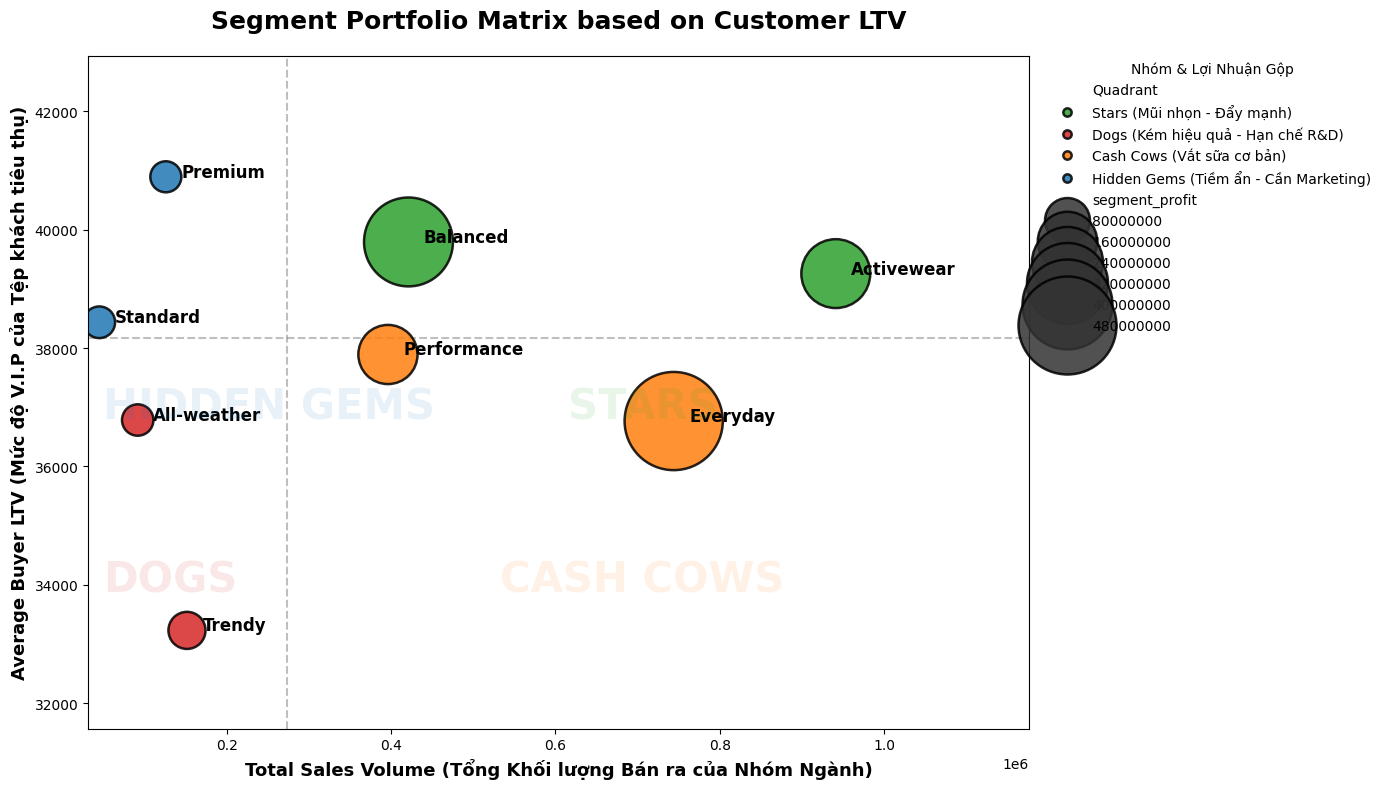

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
BASE_DATA = "data/"
orders = pd.read_csv(BASE_DATA + 'orders.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')
products = pd.read_csv(BASE_DATA + 'products.csv')

# Lọc bỏ đơn vị hủy
orders = orders[orders['order_status'] != 'cancelled']

# 2. Merge các bảng
df = order_items.merge(orders[['order_id', 'customer_id']], on='order_id', how='inner')
# TRỌNG TÂM: Lúc này ta LẤY THÊM cột 'segment' từ file products.csv
df = df.merge(products[['product_id', 'segment', 'cogs']], on='product_id', how='inner')

# 3. Tính lợi nhuận (Profit) để truy xuất Customer LTV
df['profit'] = (df['quantity'] * df['unit_price']) - df['discount_amount'].fillna(0) - (df['quantity'] * df['cogs'])

# Tính tổng LTV của từng khách hàng
customer_ltv = df.groupby('customer_id')['profit'].sum().reset_index()
customer_ltv.rename(columns={'profit': 'customer_LTV'}, inplace=True)

# Map ngược Customer LTV vào các đơn hàng họ mua
df = df.merge(customer_ltv, on='customer_id', how='left')

# ==============================================================
# 4. PHÂN TÍCH YẾU TỐ Ở CẤP ĐỘ "SEGMENT" (THAY VÌ TỪNG SẢN PHẨM)
# ==============================================================
segment_stats = df.groupby('segment').agg(
    total_sales_volume=('quantity', 'sum'),
    avg_buyer_LTV=('customer_LTV', 'mean'),  # Tập KH mua Segment này LTV trung bình là bao nhiêu
    segment_profit=('profit', 'sum')         # Tổng lợi nhuận để quyết định size bong bóng
).reset_index()

# 5. Phân bổ Quadrant dựa theo Median của 8 Segment
med_volume = segment_stats['total_sales_volume'].median()
med_ltv = segment_stats['avg_buyer_LTV'].median()

def classify_segment(row):
    if row['total_sales_volume'] >= med_volume and row['avg_buyer_LTV'] >= med_ltv:
        return 'Stars (Mũi nhọn - Đẩy mạnh)'
    elif row['total_sales_volume'] < med_volume and row['avg_buyer_LTV'] >= med_ltv:
        return 'Hidden Gems (Tiềm ẩn - Cần Marketing)'
    elif row['total_sales_volume'] >= med_volume and row['avg_buyer_LTV'] < med_ltv:
        return 'Cash Cows (Vắt sữa cơ bản)'
    else:
        return 'Dogs (Kém hiệu quả - Hạn chế R&D)'

segment_stats['Quadrant'] = segment_stats.apply(classify_segment, axis=1)

# In báo cáo bảng xịn ra Console
print("="*90)
print(f"{'PHÂN KHÚC (SEGMENT)':<20} | {'ĐỊNH HƯỚNG QUYẾT ĐỊNH':<38} | {'AVG LTV KHÁCH':<15} | {'TỔNG BÁN RA'}")
print("="*90)
for _, row in segment_stats.sort_values(by='segment_profit', ascending=False).iterrows():
    print(f"{row['segment']:<20} | {row['Quadrant']:<38} | ${row['avg_buyer_LTV']:<14,.0f} | {row['total_sales_volume']:,} Sp")

# ==========================================
# 6. TRỰC QUAN HÓA MA TRẬN SEGMENT (BUBBLE)
# ==========================================
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(
    data=segment_stats, 
    x='total_sales_volume', 
    y='avg_buyer_LTV', 
    hue='Quadrant', 
    palette={'Stars (Mũi nhọn - Đẩy mạnh)': '#2ca02c', 
             'Hidden Gems (Tiềm ẩn - Cần Marketing)': '#1f77b4', 
             'Cash Cows (Vắt sữa cơ bản)': '#ff7f0e', 
             'Dogs (Kém hiệu quả - Hạn chế R&D)': '#d62728'},
    size='segment_profit', sizes=(500, 5000), alpha=0.85, edgecolor='black', zorder=2
)

# Kẻ các đường chia ranh giới 4 mặt phẳng
plt.axvline(med_volume, color='gray', linestyle='--', alpha=0.5, zorder=1)
plt.axhline(med_ltv, color='gray', linestyle='--', alpha=0.5, zorder=1)

# Dán thẻ tên (Label) trực tiếp vào từng Bóng Segment
for _, row in segment_stats.iterrows():
    plt.text(row['total_sales_volume'] + segment_stats['total_sales_volume'].max()*0.02, 
             row['avg_buyer_LTV'], row['segment'], fontsize=12, fontweight='bold', color='black', zorder=3)

# Background Text mờ
x_max, y_max = segment_stats['total_sales_volume'].max(), segment_stats['avg_buyer_LTV'].max()
plt.text(x_max*0.75, y_max*0.9, 'STARS', fontsize=30, color='#2ca02c', alpha=0.1, weight='bold', ha='center')
plt.text(segment_stats['total_sales_volume'].min()*1.1, y_max*0.9, 'HIDDEN GEMS', fontsize=30, color='#1f77b4', alpha=0.1, weight='bold', ha='left')
plt.text(x_max*0.75, segment_stats['avg_buyer_LTV'].min()*1.02, 'CASH COWS', fontsize=30, color='#ff7f0e', alpha=0.1, weight='bold', ha='center')
plt.text(segment_stats['total_sales_volume'].min()*1.1, segment_stats['avg_buyer_LTV'].min()*1.02, 'DOGS', fontsize=30, color='#d62728', alpha=0.1, weight='bold', ha='left')


# Căn lề cho biểu đồ dễ thở (Margin X axis)
plt.xlim(segment_stats['total_sales_volume'].min() * 0.7, segment_stats['total_sales_volume'].max() * 1.25)
plt.ylim(segment_stats['avg_buyer_LTV'].min() * 0.95, segment_stats['avg_buyer_LTV'].max() * 1.05)

plt.title('Segment Portfolio Matrix based on Customer LTV', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Sales Volume (Tổng Khối lượng Bán ra của Nhóm Ngành)', fontsize=13, fontweight='bold')
plt.ylabel('Average Buyer LTV (Mức độ V.I.P của Tệp khách tiêu thụ)', fontsize=13, fontweight='bold')

# Dọn dẹp Legend
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, borderaxespad=0., title="Nhóm & Lợi Nhuận Gộp")
plt.tight_layout()
plt.show()
